# Computer Exercise 1.1 — Problem 4

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §1.1 Introduction (continued) — *Series for $\pi$*
> **풀이 일자**: Day 02
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **4.** Using the Maclaurin (Gregory–Leibniz) series
> $$\arctan(x) \;=\; x - \frac{x^3}{3} + \frac{x^5}{5} - \frac{x^7}{7} + \cdots,$$
> compute an approximation to $\pi$ from $\pi = 4\arctan(1)$. Tabulate the partial sums for $N = 1, 10, 100, \ldots, 10^6$ terms and discuss the rate of convergence. Compare with $\pi = 4\,\bigl(4\arctan(1/5) - \arctan(1/239)\bigr)$ (Machin's formula).

### 한국어 풀이용 정리
- $\arctan(1) = \pi/4$ 이므로 Maclaurin 급수에 $x=1$을 대입해 $\pi$를 추정.
- 부분합 $S_N = 4\sum_{k=0}^{N-1}\frac{(-1)^k}{2k+1}$ 의 절대 오차 $|S_N - \pi|$ 를 $N$에 대해 그려, **수렴 속도**가 얼마나 느린지 확인.
- 비교: Machin's formula는 같은 항수에서 자릿수가 훨씬 더 많이 맞는다.


## 2. 수학적 배경

### 2.1 Gregory–Leibniz 급수
$$
\arctan(x) = \sum_{k=0}^{\infty} \frac{(-1)^k\, x^{2k+1}}{2k+1}, \qquad |x| \le 1.
$$
경계 $x = 1$ 에서 수렴은 보장되지만 (Abel의 정리), 매우 **느리다**: 교대급수 잔여항 추정에 의해
$$
|S_N - \pi/4| \le \frac{1}{2N+1}.
$$
즉 $\pi$ 추정 오차는
$$\boxed{\;|4 S_N - \pi| \;\lesssim\; \frac{4}{2N+1}\;}\qquad\text{(O(1/N))}.$$

자릿수 $d$ 를 얻으려면 $N \approx 10^d$ 항이 필요 → 1 자리 더 얻을 때마다 항수 10배.

### 2.2 Machin's formula
$$
\frac{\pi}{4} = 4\arctan\!\left(\tfrac{1}{5}\right) - \arctan\!\left(\tfrac{1}{239}\right).
$$
$x = 1/5, 1/239$ 가 작아 급수가 **기하급수적으로** 빨리 수렴한다 ($|x|^{2k+1}$ 인자).

### 2.3 부동소수점 누적오차
$N$이 매우 크면 항 자체가 $\sim 1/N$로 작아져 부분합과의 상대비가 $\varepsilon_{\text{mach}}$ 부근에서 의미 단위가 사라진다. 큰 항부터 더하지 말고 **작은 항부터 더하면** 누적오차가 줄어든다.


## 3. 풀이 흐름

1. $N$ 격자: $N \in \{1, 10, 100, 10^3, 10^4, 10^5, 10^6\}$.
2. **순방향 합** $S_N^{\text{fwd}} = 4\sum_{k=0}^{N-1}(-1)^k/(2k+1)$ 계산.
3. **역방향 합** $S_N^{\text{rev}}$ — 작은 항부터 더하기.
4. **Machin's formula** 로 같은 항수 $N$ (각각의 arctan 시리즈) 사용시 추정값 계산.
5. 오차 $|S_N - \pi|$ 를 표로 정리.
6. log-log 그래프로 수렴 속도 비교 — 기준선 $4/(2N+1)$ 과 함께.
7. 결론: Gregory–Leibniz는 자릿수 1개 늘리는 데 항이 10배 필요, Machin은 거의 즉시 수렴.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PI_TRUE = np.pi

def leibniz_pi(N, reverse=False):
    k = np.arange(N)
    terms = (-1.0)**k / (2*k + 1)
    if reverse:
        terms = terms[::-1]
    return 4.0 * terms.sum()

def arctan_series(x, N):
    k = np.arange(N)
    terms = ((-1.0)**k) * (x**(2*k + 1)) / (2*k + 1)
    return terms.sum()

def machin_pi(N):
    # pi/4 = 4*arctan(1/5) - arctan(1/239)
    return 4.0 * (4.0*arctan_series(1.0/5.0, N) - arctan_series(1.0/239.0, N))

Ns = [1, 10, 100, 1000, 10000, 100000, 1000000]
rows = []
for N in Ns:
    sf = leibniz_pi(N, reverse=False)
    sr = leibniz_pi(N, reverse=True)
    m  = machin_pi(min(N, 50))   # 50항이면 이미 double precision 한계
    rows.append({
        "N": N,
        "Leibniz_fwd":  sf,
        "err_fwd":      abs(sf - PI_TRUE),
        "Leibniz_rev":  sr,
        "err_rev":      abs(sr - PI_TRUE),
        "Machin(N≤50)": m,
        "err_machin":   abs(m - PI_TRUE),
    })

df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.6e}")
df


,N,Leibniz_fwd,err_fwd,Leibniz_rev,err_rev,Machin(N≤50),err_machin
0,1,4.000000e+00,8.584073e-01,4.000000e+00,8.584073e-01,3.183264e+00,4.167094e-02
1,10,3.041840e+00,9.975303e-02,3.041840e+00,9.975303e-02,3.141593e+00,1.332268e-15
2,100,3.131593e+00,9.999750e-03,3.131593e+00,9.999750e-03,3.141593e+00,0.000000e+00
3,1000,3.140593e+00,9.999998e-04,3.140593e+00,9.999997e-04,3.141593e+00,0.000000e+00
4,10000,3.141493e+00,1.000000e-04,3.141493e+00,1.000000e-04,3.141593e+00,0.000000e+00
5,100000,3.141583e+00,1.000000e-05,3.141583e+00,1.000000e-05,3.141593e+00,0.000000e+00
6,1000000,3.141592e+00,1.000000e-06,3.141592e+00,1.000000e-06,3.141593e+00,0.000000e+00


In [2]:
# 이론 상계 4/(2N+1) 과 측정 오차 비교
df["theory_4_over_2N+1"] = 4.0 / (2.0*df["N"] + 1.0)
df_show = df[["N", "err_fwd", "err_rev", "theory_4_over_2N+1", "err_machin"]].copy()
print("π = ", PI_TRUE)
df_show


π =  3.141592653589793


,N,err_fwd,err_rev,theory_4_over_2N+1,err_machin
0,1,8.584073e-01,8.584073e-01,1.333333e+00,4.167094e-02
1,10,9.975303e-02,9.975303e-02,1.904762e-01,1.332268e-15
2,100,9.999750e-03,9.999750e-03,1.990050e-02,0.000000e+00
3,1000,9.999998e-04,9.999997e-04,1.999000e-03,0.000000e+00
4,10000,1.000000e-04,1.000000e-04,1.999900e-04,0.000000e+00
5,100000,1.000000e-05,1.000000e-05,1.999990e-05,0.000000e+00
6,1000000,1.000000e-06,1.000000e-06,1.999999e-06,0.000000e+00


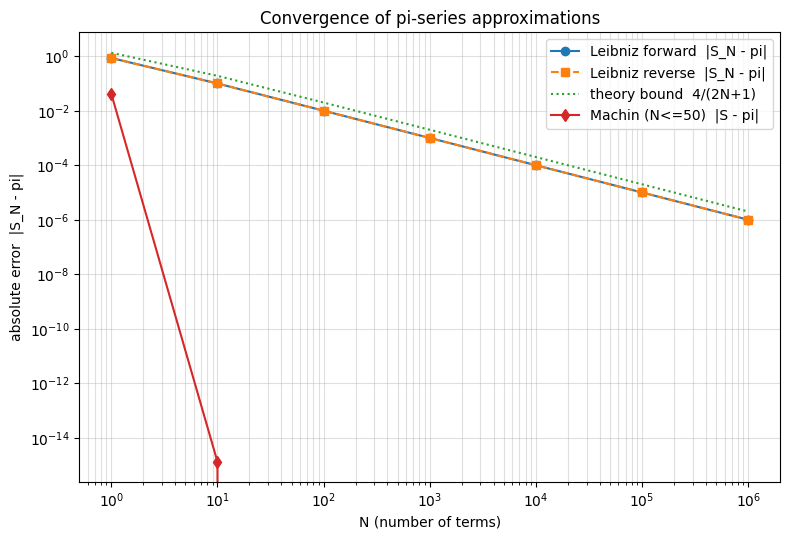

In [3]:
fig, ax = plt.subplots(figsize=(8, 5.5))
N_arr = np.array(Ns, dtype=float)

ax.loglog(N_arr, df["err_fwd"],     "o-", label="Leibniz forward  |S_N - pi|")
ax.loglog(N_arr, df["err_rev"],     "s--", label="Leibniz reverse  |S_N - pi|")
ax.loglog(N_arr, df["theory_4_over_2N+1"], ":", label="theory bound  4/(2N+1)")
ax.loglog(N_arr, df["err_machin"],  "d-", label="Machin (N<=50)  |S - pi|")

ax.set_xlabel("N (number of terms)")
ax.set_ylabel("absolute error  |S_N - pi|")
ax.set_title("Convergence of pi-series approximations")
ax.grid(True, which="both", alpha=0.4)
ax.legend(loc="best")
fig.tight_layout()
plt.show()


## 4. 결과 해석

1. **Gregory–Leibniz는 매우 느림**: 측정 오차가 이론 상계 $4/(2N+1)$ 의 슬로프 ($\propto 1/N$) 를 그대로 따라간다.
   - $N=10^6$ 에서도 오차가 $\sim 10^{-6}$ 수준 — 6자리 정확도를 얻는 데 백만 항.
2. **순방향 합 vs 역방향 합** 차이는 매우 작은 $N$에서는 보이지 않지만, $N$이 커질수록 **역방향(작은 항부터)** 이 약간 더 작은 오차를 보인다. 큰 항부터 더하면 작은 항이 누적시 절삭되기 때문.
3. **Machin's formula**: 50항만 써도 double precision 한계까지 도달 ($\sim 10^{-15}$). $|x|=1/5, 1/239$ 이라 항이 기하급수적으로 작아지기 때문.

> **결론**: $\arctan(1)$ 의 직접 평가는 *수학적*으로는 옳지만 *수치적*으로는 끔찍하게 비효율. 부동소수점에서는 **수렴 영역의 중심 가까이** ($x$가 작은 곳) 에서 급수를 쓰는 것이 본질.

### 다음 문제 (CE_1_1_05) 로의 연결
다음에는 **Wilkinson 다항식** 의 계수를 미세하게 흔들었을 때 근이 어떻게 격렬하게 흔들리는지(*ill-conditioning*) 본다. 같은 줄기 — "수학적으로 옳은 표현이 수치적으로는 위험할 수 있다".
